# Xây dựng Mô hình Phân loại và Dự báo Rủi ro Khách hàng Vay vốn

**Notebook 01/07 - Data Understanding (Tìm hiểu dữ liệu)**

---

**Mục tiêu:** Hiểu bài toán, bộ dữ liệu Home Credit, bảng chính/bảng phụ, chất lượng dữ liệu ban đầu và các vấn đề cần chuyển sang bước sau.

**Input:** `data/raw/*.csv`

**Output:** Nhận xét ban đầu về cấu trúc và chất lượng dữ liệu của bảng chính lẫn bảng phụ, quan hệ khóa giữa các bảng, biểu đồ cơ bản và tín hiệu tương quan với `TARGET`.

**Pipeline:** Business Understanding -> **Data Understanding** -> PostgreSQL Pipeline / Data Cleaning


## I. Mục tiêu notebook

Notebook này dùng để hiểu dữ liệu trước khi xử lý sâu hơn. Phạm vi của NB01 là đọc dữ liệu, mô tả bảng chính/bảng phụ, kiểm tra chất lượng ban đầu, nhận diện các vấn đề cần chuyển sang notebook sau và vẽ một số biểu đồ cần thiết để người đọc dễ nắm dữ liệu.

## II. Hiểu bài toán

Dự án giải quyết bài toán dự đoán rủi ro khách hàng vay vốn. Với bộ dữ liệu Home Credit, biến mục tiêu là `TARGET` trong bảng `application_train`.

| Giá trị `TARGET` | Ý nghĩa |
|---|---|
| `0` | Khách hàng không gặp khó khăn trong thanh toán |
| `1` | Khách hàng gặp khó khăn trong thanh toán |

Vì đầu ra chỉ có hai nhóm nên đây là bài toán **phân loại nhị phân có giám sát**.


## III. Tìm hiểu Dataset

Đoạn code bên dưới kiểm tra các file CSV thô cần có trong `data/raw`.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

# Nếu chạy notebook từ thư mục notebooks/, quay về thư mục gốc dự án.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "raw"
ERD_PATH = PROJECT_ROOT / "reports" / "images" / "home_credit_erd.png"

REQUIRED_FILES = [
    "application_train.csv",
    "application_test.csv",
    "bureau.csv",
    "bureau_balance.csv",
    "previous_application.csv",
    "installments_payments.csv",
    "POS_CASH_balance.csv",
    "credit_card_balance.csv",
    "HomeCredit_columns_description.csv",
]

CSV_ENCODINGS = ["utf-8", "cp1252", "latin1"]


def detect_csv_encoding(file_path):
    """Chọn encoding đọc CSV; file mô tả cột của Kaggle dùng encoding Windows."""
    if file_path.name == "HomeCredit_columns_description.csv":
        return "cp1252"

    return "utf-8"


missing_files = []
for file_name in REQUIRED_FILES:
    file_path = DATA_RAW / file_name
    if not file_path.exists():
        missing_files.append(file_name)

if missing_files:
    raise FileNotFoundError(
        "Thiếu file dữ liệu trong data/raw: " + ", ".join(missing_files)
    )

print("Đã tìm thấy đầy đủ các file CSV cần cho bước Data Understanding.")


Đã tìm thấy đầy đủ các file CSV cần cho bước Data Understanding.


**Nhận xét:** Các file dữ liệu thô là điều kiện đầu vào của NB01. Nếu thiếu file, các bước khảo sát bên dưới sẽ không có cơ sở để chạy đúng.


Đoạn code bên dưới tạo bảng tổng quan cho từng file CSV. Với các file lớn, dữ liệu được đọc theo từng phần nhỏ để tránh giữ toàn bộ dataset trong RAM cùng lúc.


In [2]:
def summarize_csv(file_name, chunksize=200_000):
    """Tính thông tin tổng quan của một CSV mà không giữ toàn bộ file trong RAM."""
    file_path = DATA_RAW / file_name

    total_rows = 0
    total_missing = 0
    total_cells = 0
    memory_mb = 0.0
    column_count = None

    encoding = detect_csv_encoding(file_path)

    for chunk in pd.read_csv(file_path, chunksize=chunksize, encoding=encoding):
        total_rows += len(chunk)
        total_missing += int(chunk.isna().sum().sum())
        total_cells += chunk.shape[0] * chunk.shape[1]
        memory_mb += chunk.memory_usage(deep=True).sum() / 1024**2
        column_count = chunk.shape[1]

    missing_rate = total_missing / total_cells * 100 if total_cells else 0

    return {
        "Bảng": file_name,
        "Số dòng": total_rows,
        "Số cột": column_count,
        "RAM ước tính (MB)": round(memory_mb, 1),
        "Ô thiếu (%)": round(missing_rate, 2),
    }

summary_rows = []
for file_name in REQUIRED_FILES:
    summary_rows.append(summarize_csv(file_name))

overview = pd.DataFrame(summary_rows)
overview


,Bảng,Số dòng,Số cột,RAM ước tính (MB),Ô thiếu (%)
0,application_train.csv,307511,122,325.2,24.40
1,application_test.csv,48744,121,51.2,23.81
2,bureau.csv,1716428,17,271.5,13.50
3,bureau_balance.csv,27299925,3,650.9,0.00
4,previous_application.csv,1670214,37,671.8,17.98
5,installments_payments.csv,13605401,8,830.4,0.01
6,POS_CASH_balance.csv,10001358,8,669.9,0.07
7,credit_card_balance.csv,3840312,23,696.2,6.65
8,HomeCredit_columns_description.csv,219,5,0.0,12.15


**Nhận xét:** Bảng tổng quan cho thấy Home Credit là bộ dữ liệu nhiều bảng và có quy mô lớn. Vì vậy, các bước join/aggregate ở những notebook sau cần làm cẩn thận để tránh tốn bộ nhớ hoặc làm sai số dòng.


Sơ đồ bên dưới tóm tắt quan hệ giữa bảng chính và các bảng phụ.


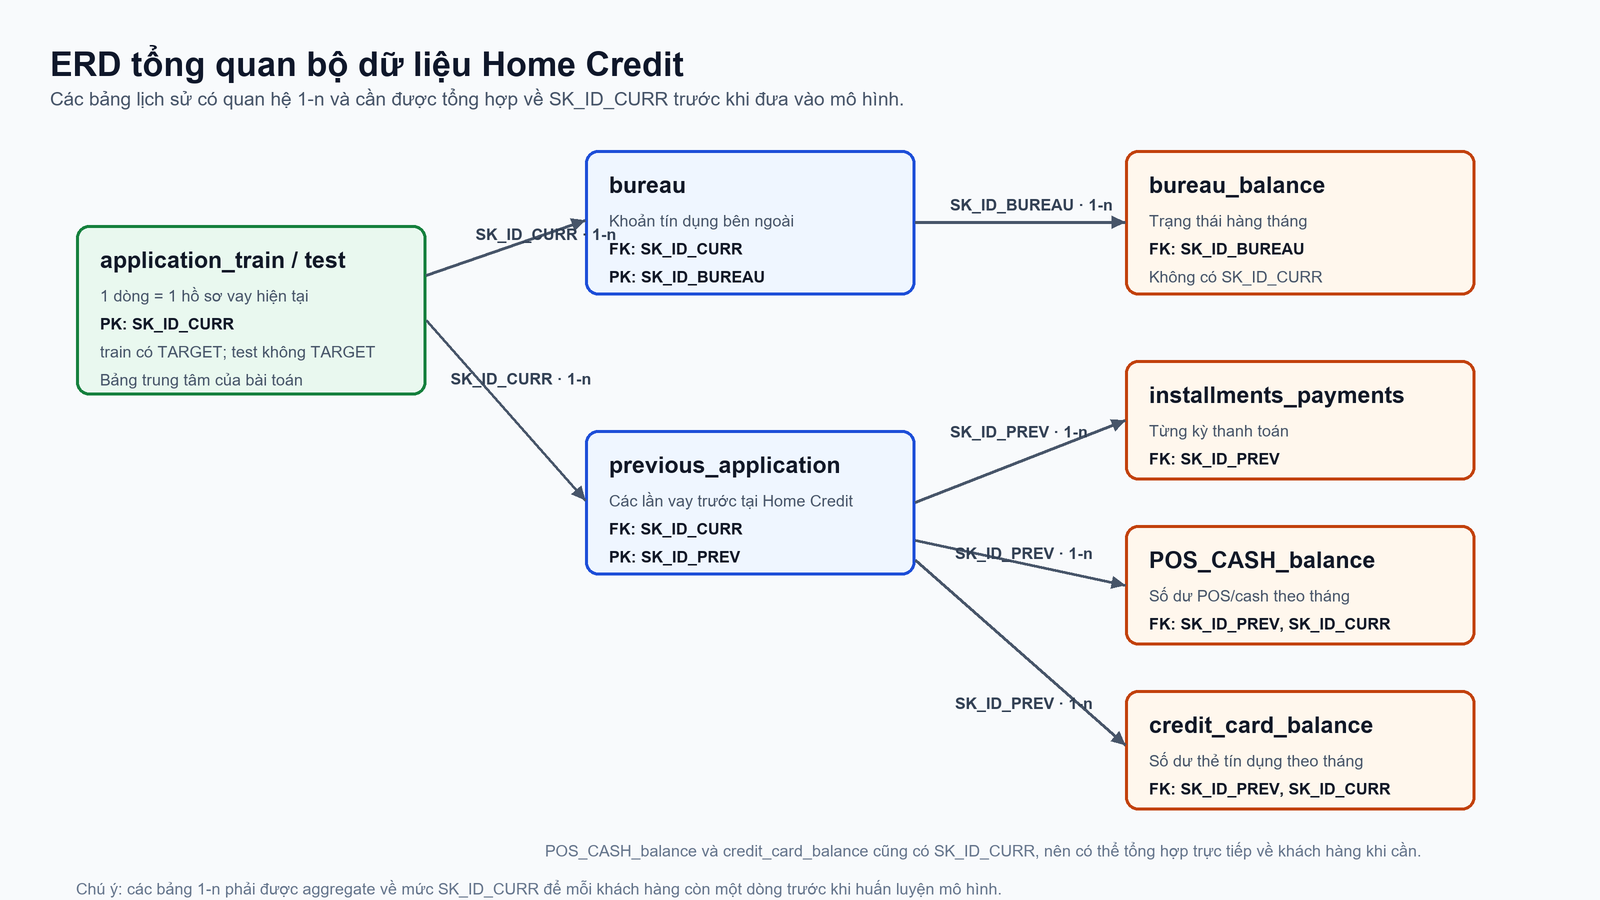

**Nhận xét:**

| Bảng chính | Bảng phụ |
|---|---|
| `application_train`, `application_test` — mỗi dòng là một hồ sơ vay hiện tại. `application_train` có thêm `TARGET` để huấn luyện mô hình; `application_test` là tập cần dự đoán. | `bureau`, `previous_application`, `installments_payments`, `POS_CASH_balance`, `credit_card_balance` — thường có nhiều dòng cho một khách hàng, nên phải tổng hợp về `SK_ID_CURR` trước khi đưa vào mô hình. |


## IV. Khảo sát dữ liệu của bảng chính

Đoạn code bên dưới đọc bảng `application_train`, bảng trung tâm có chứa biến mục tiêu `TARGET`.


In [3]:
app_train_path = DATA_RAW / "application_train.csv"
app_train_encoding = detect_csv_encoding(app_train_path)
app_train = pd.read_csv(app_train_path, encoding=app_train_encoding)

print("Số dòng:", app_train.shape[0])
print("Số cột:", app_train.shape[1])
print("RAM sử dụng (MB):", round(app_train.memory_usage(deep=True).sum() / 1024**2, 1))

app_train.head()


Số dòng: 307511
Số cột: 122
RAM sử dụng (MB): 325.2


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


**Nhận xét:** Mỗi dòng trong `application_train` là một hồ sơ vay hiện tại đã biết kết quả `TARGET`. Đây là bảng chính dùng để huấn luyện và đánh giá mô hình ở các giai đoạn sau.


Đoạn code bên dưới kiểm tra kiểu dữ liệu và số lượng cột theo từng kiểu.


In [4]:
dtype_summary = (
    app_train.dtypes
    .astype(str)
    .value_counts()
    .reset_index()
)
dtype_summary.columns = ["Kiểu dữ liệu", "Số cột"]
dtype_summary


,Kiểu dữ liệu,Số cột
0,float64,65
1,int64,41
2,str,16


**Nhận xét:** Bảng chính gồm cả biến số và biến phân loại. Các biến phân loại sẽ cần encoding ở giai đoạn Feature Engineering, còn các biến số cần kiểm tra phân phối, missing và bất thường trước khi đưa vào mô hình.


Đoạn code bên dưới nhóm một số cột quan trọng theo vai trò để người đọc không bị ngợp bởi toàn bộ 122 cột.


In [5]:
column_groups = {
    "ID và target": ["SK_ID_CURR", "TARGET"],
    "Thông tin hợp đồng": ["NAME_CONTRACT_TYPE", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"],
    "Thông tin tài chính": ["AMT_INCOME_TOTAL", "CNT_FAM_MEMBERS", "CNT_CHILDREN"],
    "Thông tin cá nhân": ["CODE_GENDER", "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS", "OCCUPATION_TYPE"],
    "Biến thời gian DAYS_*": ["DAYS_BIRTH", "DAYS_EMPLOYED", "DAYS_REGISTRATION", "DAYS_ID_PUBLISH"],
    "Điểm ngoài EXT_SOURCE": ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"],
}

rows = []
for group_name, columns in column_groups.items():
    existing_columns = []
    for column in columns:
        if column in app_train.columns:
            existing_columns.append(column)

    rows.append({
        "Nhóm cột": group_name,
        "Các cột tiêu biểu": ", ".join(existing_columns),
        "Số cột có trong dữ liệu": len(existing_columns),
    })

column_group_df = pd.DataFrame(rows)

# Hiển thị đầy đủ tên cột, không rút gọn bằng dấu ba chấm.
with pd.option_context("display.max_colwidth", None):
    display(column_group_df)


,Nhóm cột,Các cột tiêu biểu,Số cột có trong dữ liệu
0,ID và target,"SK_ID_CURR, TARGET",2
1,Thông tin hợp đồng,"NAME_CONTRACT_TYPE, AMT_CREDIT, AMT_ANNUITY, AMT_GOODS_PRICE",4
2,Thông tin tài chính,"AMT_INCOME_TOTAL, CNT_FAM_MEMBERS, CNT_CHILDREN",3
3,Thông tin cá nhân,"CODE_GENDER, NAME_EDUCATION_TYPE, NAME_FAMILY_STATUS, OCCUPATION_TYPE",4
4,Biến thời gian DAYS_*,"DAYS_BIRTH, DAYS_EMPLOYED, DAYS_REGISTRATION, DAYS_ID_PUBLISH",4
5,Điểm ngoài EXT_SOURCE,"EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3",3


**Nhận xét:** Cách nhóm cột giúp notebook tập trung vào ý nghĩa nghiệp vụ của dữ liệu thay vì liệt kê toàn bộ cột một cách máy móc.


Đoạn code bên dưới kiểm tra số lượng giá trị khác nhau (`nunique`) cho các cột tiêu biểu trong bảng chính.


In [6]:
nunique_rows = []
for group_name, columns in column_groups.items():
    for column in columns:
        if column in app_train.columns:
            unique_count = app_train[column].nunique(dropna=False)
            unique_rate = unique_count / len(app_train) * 100

            nunique_rows.append({
                "Nhóm cột": group_name,
                "Cột": column,
                "Số giá trị khác nhau": int(unique_count),
                "Tỷ lệ unique (%)": round(unique_rate, 2),
            })

nunique_summary = pd.DataFrame(nunique_rows)
nunique_summary = nunique_summary.sort_values(
    ["Nhóm cột", "Số giá trị khác nhau"],
    ascending=[True, False],
)

nunique_summary


,Nhóm cột,Cột,Số giá trị khác nhau,Tỷ lệ unique (%)
13,Biến thời gian DAYS_*,DAYS_BIRTH,17460,5.68
15,Biến thời gian DAYS_*,DAYS_REGISTRATION,15688,5.10
14,Biến thời gian DAYS_*,DAYS_EMPLOYED,12574,4.09
16,Biến thời gian DAYS_*,DAYS_ID_PUBLISH,6168,2.01
0,ID và target,SK_ID_CURR,307511,100.00
1,ID và target,TARGET,2,0.00
12,Thông tin cá nhân,OCCUPATION_TYPE,19,0.01
11,Thông tin cá nhân,NAME_FAMILY_STATUS,6,0.00
10,Thông tin cá nhân,NAME_EDUCATION_TYPE,5,0.00
9,Thông tin cá nhân,CODE_GENDER,3,0.00


**Nhận xét:** Bảng `nunique` giúp phân biệt nhanh nhóm cột định danh, nhóm phân loại và nhóm numeric liên tục:

- `SK_ID_CURR` có số giá trị khác nhau rất cao, phù hợp vai trò khóa định danh hồ sơ.
- `TARGET` chỉ có 2 giá trị, đúng với bài toán phân loại nhị phân.
- Các biến phân loại như `CODE_GENDER`, `NAME_CONTRACT_TYPE`, `NAME_EDUCATION_TYPE`, `NAME_FAMILY_STATUS` có cardinality thấp, phù hợp để kiểm tra `value_counts()` và encoding ở NB04/NB05.
- Các biến tiền tệ và `DAYS_*` có nhiều giá trị khác nhau hơn, nên cần xem thêm phân phối, outlier và mã đặc biệt trước khi đưa vào mô hình.


### **Thống kê mô tả** cho các biến numeric tiêu biểu/có khả năng liên quan đến rủi ro tín dụng trong bảng chính.


In [7]:
selected_numeric_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
]

existing_numeric_cols = []
for column in selected_numeric_cols:
    if column in app_train.columns:
        existing_numeric_cols.append(column)

app_train[existing_numeric_cols].describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.92,237123.15,25650.00,112500.00,147150.00,202500.00,1.170000e+08
AMT_CREDIT,307511.0,599026.00,402490.78,45000.00,270000.00,513531.00,808650.00,4.050000e+06
AMT_ANNUITY,307499.0,27108.57,14493.74,1615.50,16524.00,24903.00,34596.00,2.580255e+05
DAYS_BIRTH,307511.0,-16037.00,4363.99,-25229.00,-19682.00,-15750.00,-12413.00,-7.489000e+03
DAYS_EMPLOYED,307511.0,63815.05,141275.77,-17912.00,-2760.00,-1213.00,-289.00,3.652430e+05
EXT_SOURCE_1,134133.0,0.50,0.21,0.01,0.33,0.51,0.68,9.600000e-01
EXT_SOURCE_2,306851.0,0.51,0.19,0.00,0.39,0.57,0.66,8.500000e-01
EXT_SOURCE_3,246546.0,0.51,0.19,0.00,0.37,0.54,0.67,9.000000e-01


Qua thống kê, kiểm chứng thêm một số giá trị đặc biệt/bất thường thường gặp trong bảng chính.


In [8]:
days_employed_special = (app_train["DAYS_EMPLOYED"] == 365243).sum()
code_gender_xna = (app_train["CODE_GENDER"] == "XNA").sum()

money_columns = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"]
money_summary = app_train[money_columns].agg(["min", "median", "max"]).T
money_summary = money_summary.rename(columns={
    "min": "Giá trị nhỏ nhất",
    "median": "Trung vị",
    "max": "Giá trị lớn nhất",
})

print("Số dòng DAYS_EMPLOYED = 365243:", int(days_employed_special))
print("Số dòng CODE_GENDER = XNA:", int(code_gender_xna))

money_summary.round(2)


Số dòng DAYS_EMPLOYED = 365243: 55374
Số dòng CODE_GENDER = XNA: 4


,Giá trị nhỏ nhất,Trung vị,Giá trị lớn nhất
AMT_INCOME_TOTAL,25650.0,147150.0,117000000.0
AMT_CREDIT,45000.0,513531.0,4050000.0
AMT_ANNUITY,1615.5,24903.0,258025.5


**Nhận xét:** Kết hợp bảng thống kê mô tả và kết quả kiểm chứng ở trên, có thể ghi nhận các điểm sau:

- `AMT_INCOME_TOTAL` có giá trị `max` rất lớn so với trung vị, cho thấy có outlier thu nhập.
- `AMT_CREDIT` và `AMT_ANNUITY` cũng có giá trị lớn hơn mặt bằng chung, cần xem thêm phân phối trước khi quyết định xử lý.
- `DAYS_BIRTH` là số âm do dataset mã hóa số ngày tính lùi từ thời điểm nộp hồ sơ, nên không xem là lỗi.
- `DAYS_EMPLOYED = 365243` là giá trị numeric bất thường, không hợp lý về nghiệp vụ vì tương đương khoảng 1000 năm làm việc.
- `CODE_GENDER = XNA` là giá trị phân loại đặc biệt, không thuộc nhóm `M/F`.
- `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3` nằm trong khoảng 0-1, nhưng cần kiểm tra thêm missing và tương quan với `TARGET`.

Các điểm này chỉ được ghi nhận ở NB01. Việc xử lý cụ thể có thể sẽ chuyển sang giai đoạn Data Cleaning/ .


## V. Kiểm tra chất lượng dữ liệu của bảng chính

Đoạn code bên dưới kiểm tra các cột có tỷ lệ missing cao nhất trong bảng chính.


In [9]:
missing_count = app_train.isna().sum()
missing_rate = missing_count / len(app_train) * 100

missing_summary = pd.DataFrame({
    "Cột": missing_count.index,
    "Số ô thiếu": missing_count.values,
    "Tỷ lệ thiếu (%)": missing_rate.values,
})

missing_summary = missing_summary[missing_summary["Số ô thiếu"] > 0]
missing_summary = missing_summary.sort_values("Tỷ lệ thiếu (%)", ascending=False)
missing_summary["Tỷ lệ thiếu (%)"] = missing_summary["Tỷ lệ thiếu (%)"].round(2)

top_missing = missing_summary.head(20)
top_missing


,Cột,Số ô thiếu,Tỷ lệ thiếu (%)
76,COMMONAREA_MEDI,214865,69.87
62,COMMONAREA_MODE,214865,69.87
48,COMMONAREA_AVG,214865,69.87
70,NONLIVINGAPARTMENTS_MODE,213514,69.43
84,NONLIVINGAPARTMENTS_MEDI,213514,69.43
56,NONLIVINGAPARTMENTS_AVG,213514,69.43
86,FONDKAPREMONT_MODE,210295,68.39
54,LIVINGAPARTMENTS_AVG,210199,68.35
82,LIVINGAPARTMENTS_MEDI,210199,68.35
68,LIVINGAPARTMENTS_MODE,210199,68.35


**Nhận xét:** Các cột thiếu nhiều có thể cần được xem xét kỹ ở  . Ở NB01, nhóm chỉ ghi nhận vấn đề, chưa chọn cách imputation hay xóa cột.


Đoạn code bên dưới vẽ top cột missing để người đọc dễ nhìn mức độ thiếu dữ liệu.


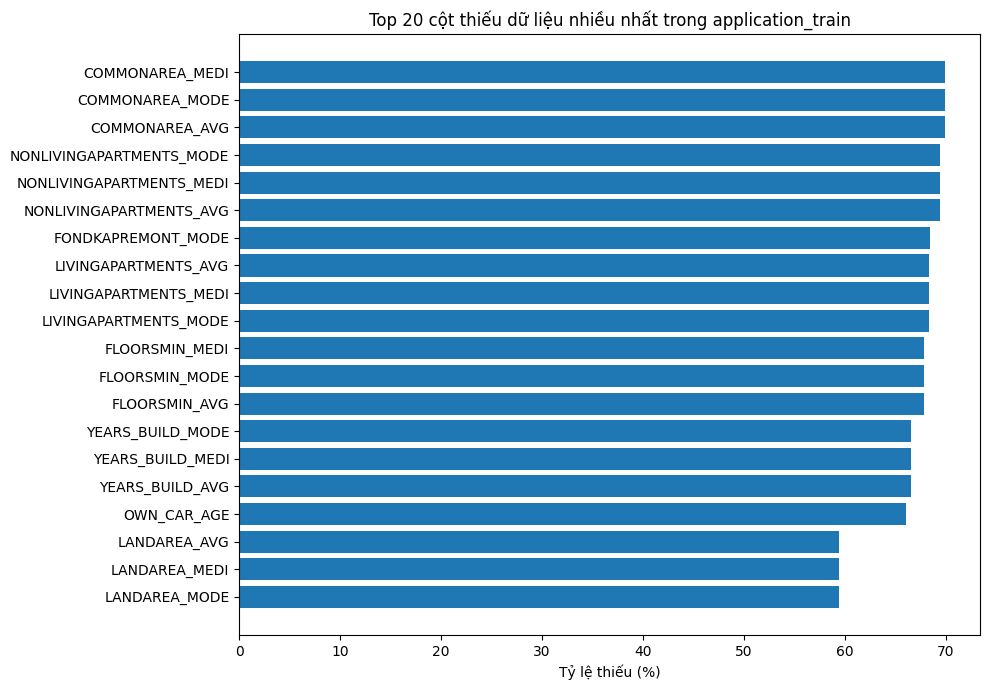

In [10]:
plt.figure(figsize=(10, 7))
plt.barh(top_missing["Cột"], top_missing["Tỷ lệ thiếu (%)"])
plt.gca().invert_yaxis()
plt.xlabel("Tỷ lệ thiếu (%)")
plt.title("Top 20 cột thiếu dữ liệu nhiều nhất trong application_train")
plt.tight_layout()
plt.show()


**Nhận xét:** Biểu đồ missing giúp xác định nhóm cột cần ưu tiên kiểm tra ở Data Cleaning. Cột thiếu nhiều chưa chắc vô dụng, nhưng không thể đưa thẳng vào mô hình nếu chưa xử lý.


Đoạn code bên dưới kiểm tra duplicate toàn dòng và duplicate theo khóa `SK_ID_CURR`.


In [11]:
duplicate_rows = app_train.duplicated().sum()
duplicate_ids = app_train["SK_ID_CURR"].duplicated().sum()

pd.DataFrame([
    {"Kiểm tra": "Duplicate toàn dòng", "Số lượng": int(duplicate_rows)},
    {"Kiểm tra": "Duplicate theo SK_ID_CURR", "Số lượng": int(duplicate_ids)},
])


,Kiểm tra,Số lượng
0,Duplicate toàn dòng,0
1,Duplicate theo SK_ID_CURR,0


**Nhận xét:** `SK_ID_CURR` cần là khóa đại diện cho hồ sơ/khách hàng trong bảng chính. Nếu có duplicate ở khóa này, các bước join và modeling sau sẽ cần kiểm tra lại rất kỹ.


Đoạn code bên dưới kiểm tra phân bố biến mục tiêu `TARGET`.


In [12]:
target_count = app_train["TARGET"].value_counts().sort_index()
target_rate = app_train["TARGET"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "TARGET": target_count.index,
    "Số lượng": target_count.values,
    "Tỷ lệ (%)": target_rate.round(2).values,
})

target_summary


,TARGET,Số lượng,Tỷ lệ (%)
0,0,282686,91.93
1,1,24825,8.07


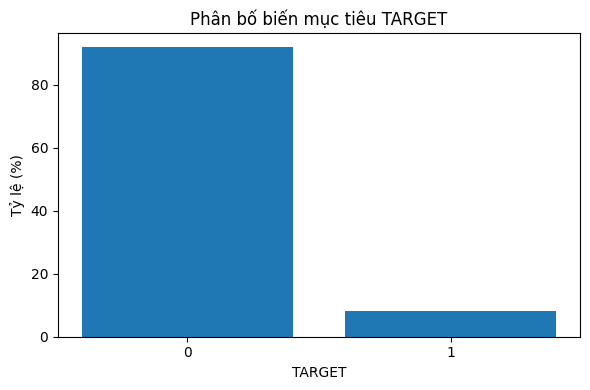

In [13]:
plt.figure(figsize=(6, 4))
plt.bar(target_summary["TARGET"].astype(str), target_summary["Tỷ lệ (%)"])
plt.xlabel("TARGET")
plt.ylabel("Tỷ lệ (%)")
plt.title("Phân bố biến mục tiêu TARGET")
plt.tight_layout()
plt.show()


**Nhận xét:** Nếu `TARGET = 1` chiếm tỷ lệ nhỏ hơn nhiều so với `TARGET = 0`, dữ liệu bị mất cân bằng lớp. Điều này ảnh hưởng trực tiếp đến cách đánh giá mô hình ở NB06, vì accuracy có thể gây hiểu nhầm.


## VI. Khảo sát các nhóm dữ liệu của bảng chính

Đoạn code bên dưới vẽ phân phối một số biến numeric tiêu biểu/có khả năng liên quan đến rủi ro tín dụng. Một số biểu đồ giới hạn trục theo phân vị 99% để dễ nhìn outlier, nhưng dữ liệu gốc không bị thay đổi.


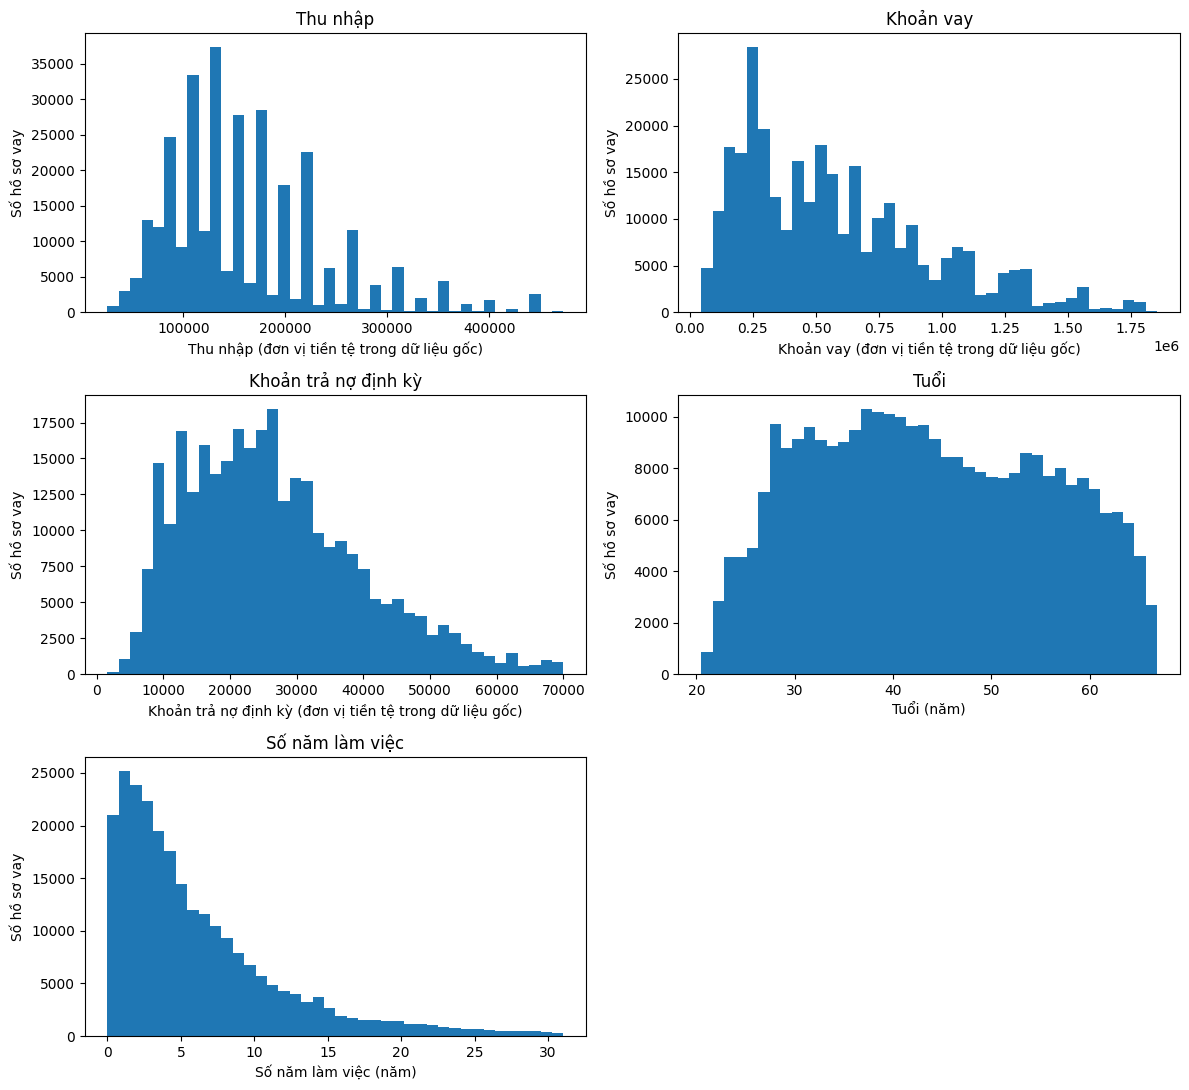

In [14]:
numeric_plot_data = pd.DataFrame()
numeric_plot_data["Thu nhập"] = app_train["AMT_INCOME_TOTAL"]
numeric_plot_data["Khoản vay"] = app_train["AMT_CREDIT"]
numeric_plot_data["Khoản trả nợ định kỳ"] = app_train["AMT_ANNUITY"]
numeric_plot_data["Tuổi"] = -app_train["DAYS_BIRTH"] / 365.25

# DAYS_EMPLOYED = 365243 là mã đặc biệt. Loại riêng khỏi biểu đồ để nhìn phần còn lại rõ hơn.
employed_days = app_train["DAYS_EMPLOYED"]
employed_days = employed_days[employed_days != 365243]
numeric_plot_data["Số năm làm việc"] = -employed_days / 365.25

plot_columns = ["Thu nhập", "Khoản vay", "Khoản trả nợ định kỳ", "Tuổi", "Số năm làm việc"]
x_labels = {
    "Thu nhập": "Thu nhập (đơn vị tiền tệ trong dữ liệu gốc)",
    "Khoản vay": "Khoản vay (đơn vị tiền tệ trong dữ liệu gốc)",
    "Khoản trả nợ định kỳ": "Khoản trả nợ định kỳ (đơn vị tiền tệ trong dữ liệu gốc)",
    "Tuổi": "Tuổi (năm)",
    "Số năm làm việc": "Số năm làm việc (năm)",
}

fig, axes = plt.subplots(3, 2, figsize=(12, 11))
axes = axes.ravel()

for index, column in enumerate(plot_columns):
    values = numeric_plot_data[column].dropna()
    upper_limit = values.quantile(0.99)

    axes[index].hist(values[values <= upper_limit], bins=40)
    axes[index].set_title(column)
    axes[index].set_xlabel(x_labels[column])
    axes[index].set_ylabel("Số hồ sơ vay")

axes[-1].axis("off")
plt.tight_layout()
plt.show()


**Nhận xét:** Các biểu đồ trên là histogram: trục X là giá trị của biến (tiền tệ theo đơn vị gốc hoặc năm), còn trục Y là số hồ sơ vay trong từng khoảng giá trị.

- `Thu nhập` (`AMT_INCOME_TOTAL`): phân phối lệch phải, đa số hồ sơ tập trung ở vùng thu nhập thấp/trung bình, trong khi một số ít hồ sơ có thu nhập rất cao. Đây là dấu hiệu cần kiểm tra outlier.
- `Khoản vay` (`AMT_CREDIT`): phân phối cũng lệch phải, cho thấy phần lớn khoản vay nằm ở mức vừa phải và chỉ một nhóm nhỏ có khoản vay rất lớn. Biến này nên được xem cùng thu nhập và khoản trả nợ định kỳ để đánh giá gánh nặng vay ở các bước sau.
- `Khoản trả nợ định kỳ` (`AMT_ANNUITY`): đây là số tiền khách hàng phải trả ở mỗi kỳ vay. Phân phối có xu hướng tương tự khoản vay, tức là đa số khoản trả ở mức thấp/trung bình và có một số giá trị cao. NB04 có thể tạo thêm tỷ lệ như `AMT_ANNUITY / AMT_INCOME_TOTAL` để hiểu khả năng trả nợ.
- `Tuổi` (`DAYS_BIRTH` sau khi đổi dấu và chia cho 365.25): phân phối tập trung ở nhóm khách hàng trưởng thành/trung niên. Đây là biến nhân khẩu học cần kiểm tra thêm theo từng nhóm `TARGET` để xem nhóm tuổi nào có rủi ro cao hơn.
- `Số năm làm việc` (`DAYS_EMPLOYED` sau khi loại mã đặc biệt `365243`): nhiều hồ sơ có số năm làm việc không quá lớn, trong khi một số ít có thâm niên cao. Việc loại riêng `365243` giúp biểu đồ phản ánh phần dữ liệu hợp lý hơn.

Các biểu đồ đang giới hạn ở phân vị 99% để dễ nhìn phần lớn dữ liệu; dữ liệu gốc chưa bị thay đổi. Insight chính là các biến tài chính có đuôi phải dài, cần xử lý outlier/mã đặc biệt và có thể cân nhắc biến tỷ lệ hoặc biến đã biến đổi log.


Đoạn code bên dưới vẽ phân bố một số biến phân loại tiêu biểu/có khả năng liên quan đến rủi ro tín dụng.


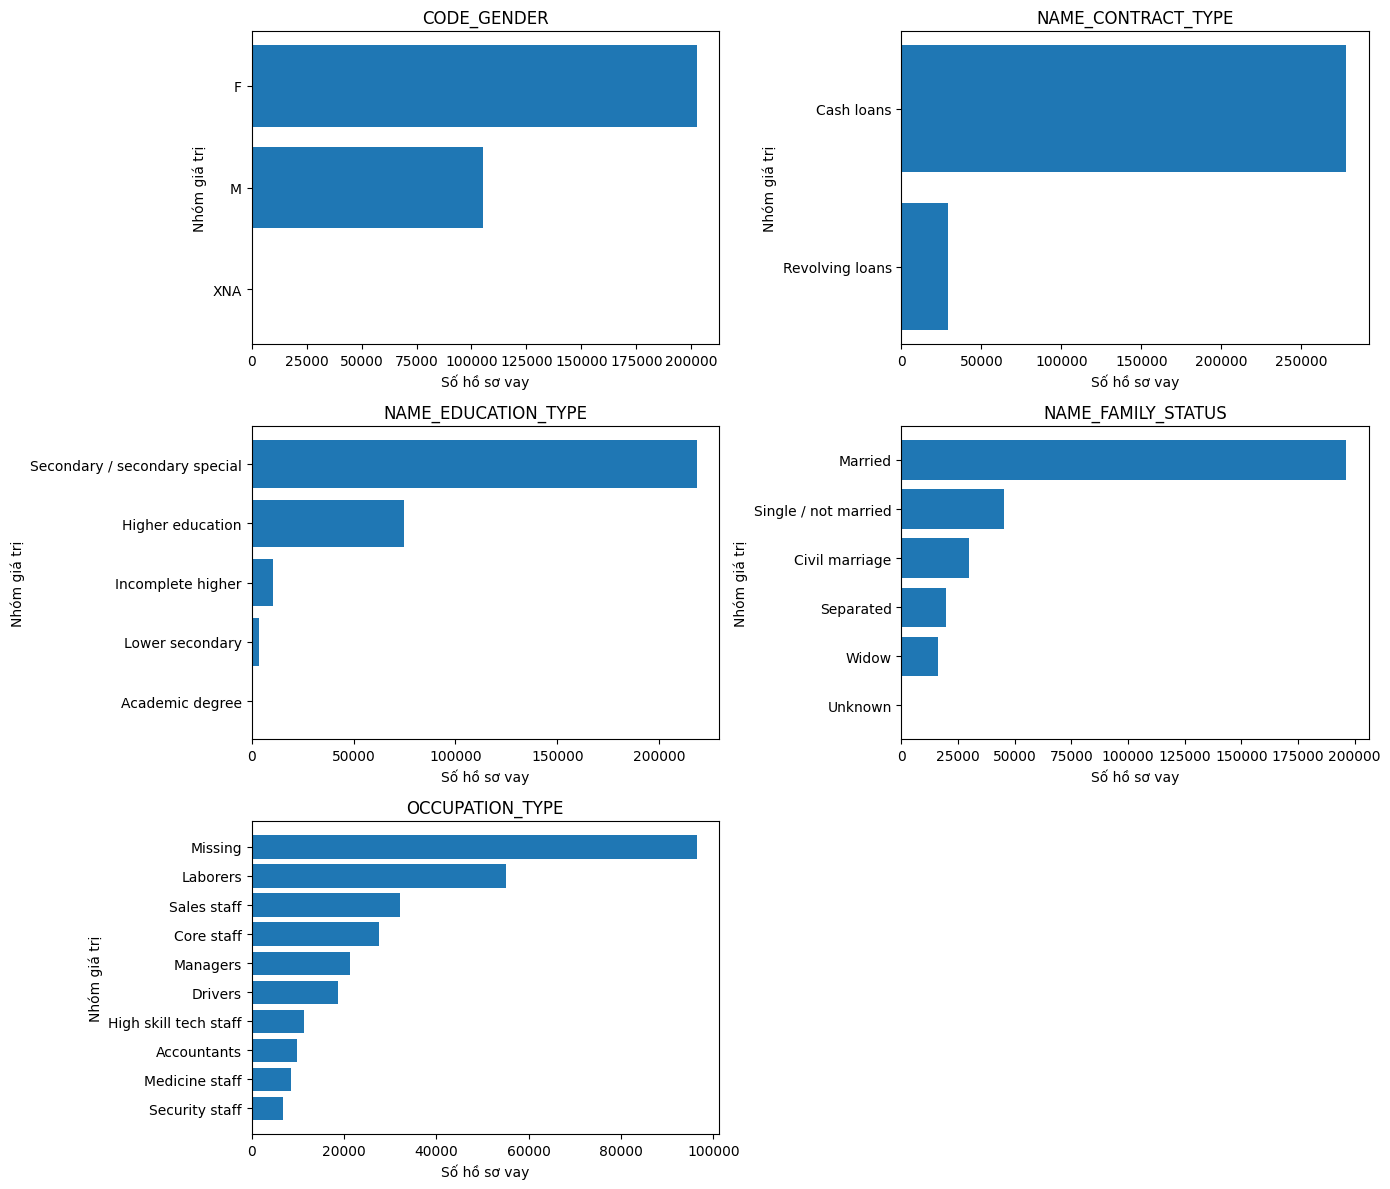

In [15]:
category_columns = [
    "CODE_GENDER",
    "NAME_CONTRACT_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "OCCUPATION_TYPE",
]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.ravel()

for index, column in enumerate(category_columns):
    counts = app_train[column].fillna("Missing").value_counts().head(10)

    axes[index].barh(counts.index.astype(str), counts.values)
    axes[index].invert_yaxis()
    axes[index].set_title(column)
    axes[index].set_xlabel("Số hồ sơ vay")
    axes[index].set_ylabel("Nhóm giá trị")

axes[-1].axis("off")
plt.tight_layout()
plt.show()


**Nhận xét:** Các biểu đồ trên là bar chart: trục X là số hồ sơ vay, còn trục Y là từng nhóm giá trị của biến phân loại.

- `CODE_GENDER`: nhóm `F` chiếm nhiều hơn nhóm `M`, trong khi `XNA` chỉ có 4 dòng. `XNA` là giá trị rất hiếm và không rõ nghĩa nghiệp vụ.
- `NAME_CONTRACT_TYPE`: `Cash loans` chiếm đa số lớn, còn `Revolving loans` ít hơn nhiều. Điều này cho thấy dữ liệu bị lệch theo loại hợp đồng, nên khi đánh giá mô hình cần chú ý mô hình có học tốt cho nhóm hợp đồng ít hơn hay không.
- `NAME_EDUCATION_TYPE`: phần lớn khách hàng thuộc nhóm `Secondary / secondary special`, tiếp theo là `Higher education`. Các nhóm như `Academic degree` rất hiếm, cần cân nhắc cách encoding để tránh tạo đặc trưng quá thưa.
- `NAME_FAMILY_STATUS`: nhóm `Married` chiếm tỷ trọng lớn nhất, các nhóm còn lại nhỏ hơn rõ rệt. Biến này có thể phản ánh bối cảnh gia đình của khách hàng và nên được kiểm tra thêm theo `TARGET`.
- `OCCUPATION_TYPE`: có lượng `Missing` lớn, đồng thời các nghề phổ biến như `Laborers`, `Sales staff`, `Core staff`, `Managers` chiếm tỷ trọng đáng kể. Đây là biến vừa có ý nghĩa nghiệp vụ vừa có vấn đề missing, nên cần ưu tiên xử lý ở   trước khi encoding.

Insight chính là các biến phân loại có phân bố không đều và có một số nhóm hiếm/missing, ở NB04 cần chọn cách encoding phù hợp để mô hình không bị nhiễu bởi nhóm quá hiếm.

Đoạn code bên dưới tính tương quan ban đầu giữa các biến numeric và `TARGET`.


In [16]:
numeric_columns = app_train.select_dtypes(include=["number"]).columns.tolist()

correlations = app_train[numeric_columns].corr(numeric_only=True)["TARGET"]
correlations = correlations.drop(labels=["TARGET"])
correlations = correlations.dropna()

correlation_summary = pd.DataFrame({
    "Cột": correlations.index,
    "Correlation với TARGET": correlations.values,
})
correlation_summary["Abs correlation"] = correlation_summary["Correlation với TARGET"].abs()
correlation_summary = correlation_summary.sort_values("Abs correlation", ascending=False)

top_corr = correlation_summary.head(20)
top_corr.round(2)


,Cột,Correlation với TARGET,Abs correlation
30,EXT_SOURCE_3,-0.18,0.18
29,EXT_SOURCE_2,-0.16,0.16
28,EXT_SOURCE_1,-0.16,0.16
7,DAYS_BIRTH,0.08,0.08
20,REGION_RATING_CLIENT_W_CITY,0.06,0.06
19,REGION_RATING_CLIENT,0.06,0.06
78,DAYS_LAST_PHONE_CHANGE,0.06,0.06
10,DAYS_ID_PUBLISH,0.05,0.05
26,REG_CITY_NOT_WORK_CITY,0.05,0.05
13,FLAG_EMP_PHONE,0.05,0.05


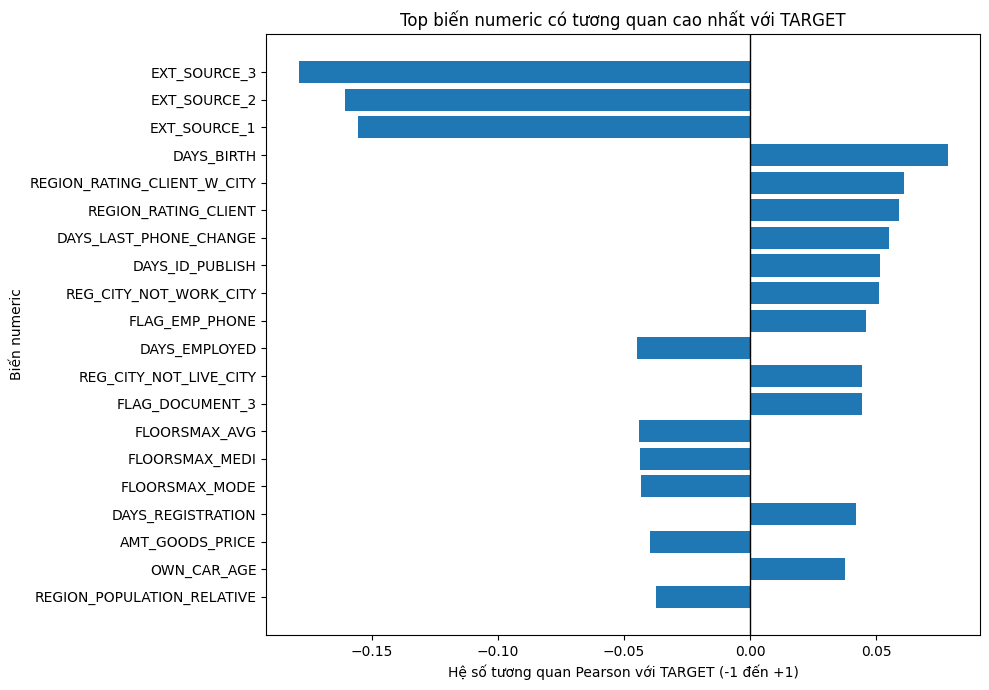

In [17]:
plt.figure(figsize=(10, 7))
plt.barh(top_corr["Cột"], top_corr["Correlation với TARGET"])
plt.gca().invert_yaxis()
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Hệ số tương quan Pearson với TARGET (-1 đến +1)")
plt.ylabel("Biến numeric")
plt.title("Top biến numeric có tương quan cao nhất với TARGET")
plt.tight_layout()
plt.show()


**Nhận xét:** Ở biểu đồ correlation, trục X là hệ số tương quan Pearson với `TARGET` (từ -1 đến +1); trục Y là các biến numeric. Cột âm cho thấy biến tăng đi kèm xu hướng `TARGET = 1` giảm, còn cột dương cho thấy xu hướng ngược lại.

- `EXT_SOURCE_3`, `EXT_SOURCE_2`, `EXT_SOURCE_1` là ba biến có độ tương quan tuyến tính cao nhất với `TARGET` và đều mang dấu âm. Điều này gợi ý điểm nguồn ngoài càng cao thì xác suất `TARGET = 1` có xu hướng thấp hơn.
- `DAYS_BIRTH` có correlation dương với `TARGET`, nhưng cần nhớ cột này đang được mã hóa bằng số ngày âm. Giá trị càng lớn tức là khách hàng càng trẻ hơn, nên NB04 nên đổi sang tuổi để phân tích dễ hiểu hơn.
- `REGION_RATING_CLIENT_W_CITY`, `REGION_RATING_CLIENT` và một số biến địa lý/hồ sơ cũng xuất hiện trong top correlation, cho thấy thông tin bối cảnh khách hàng có thể hữu ích cho EDA và Feature Engineering.
- Các biến tài chính đơn lẻ như `AMT_GOODS_PRICE` có correlation thấp hơn nhóm `EXT_SOURCE`, nên xem thêm biến tỷ lệ như gánh nặng trả nợ thay vì chỉ dùng giá trị gốc.

Correlation chỉ là tín hiệu ban đầu, không chứng minh quan hệ nhân quả. Biến có correlation thấp cũng chưa chắc vô dụng, vì mô hình có thể học quan hệ phi tuyến hoặc tương tác giữa nhiều biến.


Biểu đồ dưới đây đo **hệ số tương quan** giữa từng cặp biến. Cách đọc:

- Ô **đỏ** (số dương): hai biến cùng chiều — biến này tăng thì biến kia cũng tăng.
- Ô **xanh** (số âm): hai biến ngược chiều — biến này tăng thì biến kia giảm.
- Ô **trắng nhạt** (gần 0): hai biến gần như không liên quan.

Dấu cho biết *hướng*, còn độ lớn bỏ dấu cho biết *độ mạnh*. Vì vậy `-0,60` và `+0,60` mạnh ngang nhau, chỉ ngược hướng nhau.


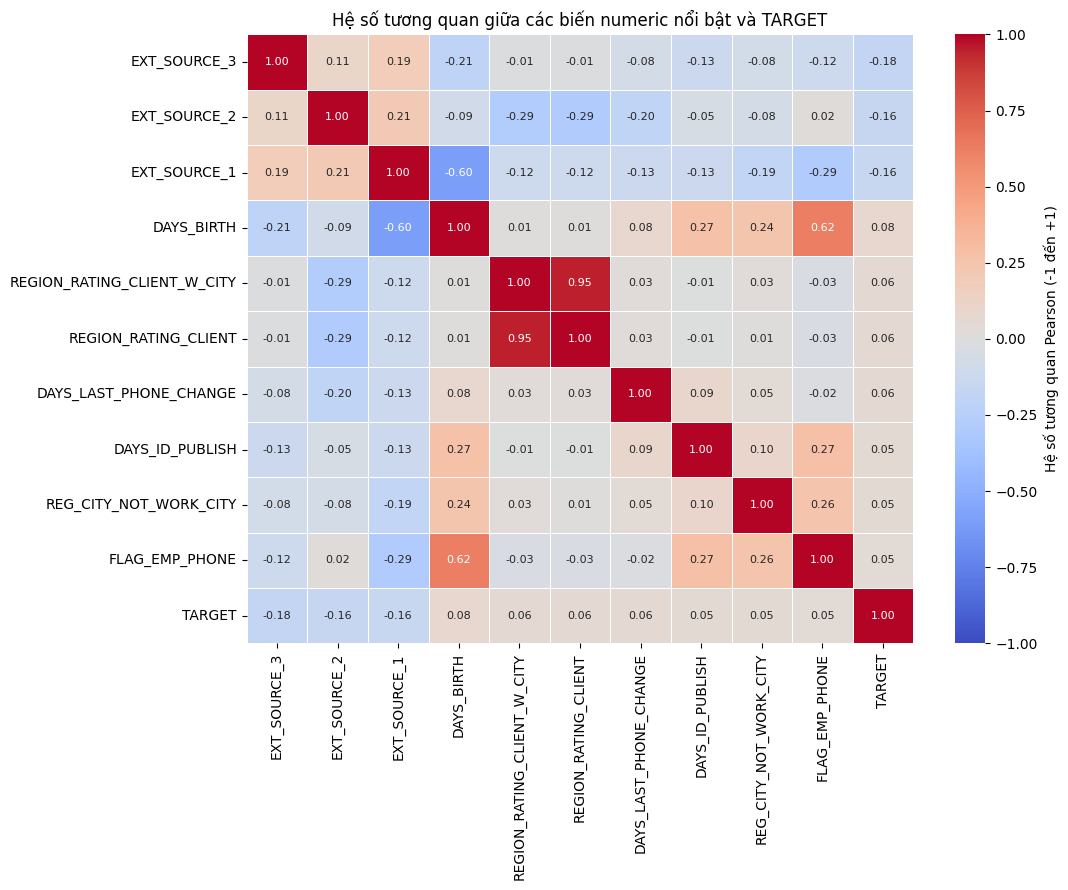

In [18]:
heatmap_columns = top_corr["Cột"].head(10).tolist()
heatmap_columns.append("TARGET")

plt.figure(figsize=(11, 9))
sns.heatmap(
    app_train[heatmap_columns].corr(),
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,      # hiện số ngay trên ô, không phải đoán qua màu
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.5,
    cbar_kws={"label": "Hệ số tương quan Pearson (-1 đến +1)"},
)
plt.title("Hệ số tương quan giữa các biến numeric nổi bật và TARGET")
plt.tight_layout()
plt.show()

**Nhận xét:** Bốn điều rút ra từ heatmap.

**1. Không biến nào một mình dự đoán được vỡ nợ.** Cột `TARGET` không có ô nào đậm — biến mạnh nhất là `EXT_SOURCE_3` cũng chỉ đạt `-0,18`. Đây là phát hiện quan trọng nhất của mục này: tín hiệu phải đến từ việc **kết hợp nhiều biến**, nên không thể chọn vài cột rồi huấn luyện ngay mà cần bước Feature Engineering ở Notebook 05.

**2. Ba biến `EXT_SOURCE` đều mang dấu âm** (`-0,16` đến `-0,18`): điểm tín dụng từ nguồn bên ngoài càng cao thì rủi ro vỡ nợ càng thấp. Đúng với logic nghiệp vụ và đây là nhóm biến mạnh nhất của bộ dữ liệu.

**3. `DAYS_BIRTH` đạt `+0,08` nghĩa là khách hàng trẻ có rủi ro cao hơn.** Chỗ này dễ đọc ngược: `DAYS_BIRTH` là số âm đếm lùi từ ngày nộp hồ sơ, nên giá trị càng gần 0 thì khách càng trẻ. Tương quan dương nghĩa là càng gần 0 thì `TARGET` càng tăng.

**4. Hai cột `REGION_RATING_CLIENT_W_CITY` và `REGION_RATING_CLIENT` gần như trùng nhau** (`+0,95`), nên chúng lặp lại cùng một thông tin và Notebook 05 chỉ nên giữ lại một. Tương tự, cặp `EXT_SOURCE_1` với `DAYS_BIRTH` (`-0,60`) và cặp `DAYS_BIRTH` với `FLAG_EMP_PHONE` (`+0,62`) cho thấy độ tuổi chi phối khá nhiều biến khác — hai ô này mạnh ngang nhau nhưng ngược hướng.

Các quan sát trên chỉ để đặt câu hỏi cho NB04/NB05, chưa dùng để loại biến ngay trong NB01.


## VII. Khảo sát dữ liệu của bảng phụ


Sáu bảng phụ được khảo sát bằng một hàm dùng chung thay vì lặp lại từng bảng. Hàm đọc theo chunk nên `bureau_balance` 27,3 triệu dòng vẫn chạy được trên máy cá nhân.


In [19]:
SUB_TABLES = [
    "bureau.csv",
    "bureau_balance.csv",
    "previous_application.csv",
    "installments_payments.csv",
    "POS_CASH_balance.csv",
    "credit_card_balance.csv",
]


def survey_sub_table(file_name, chunksize=200_000):
    """Gom thông tin khảo sát cơ bản của một bảng phụ, đọc theo chunk để nhẹ RAM."""
    file_path = DATA_RAW / file_name
    encoding = detect_csv_encoding(file_path)

    total_rows = 0
    total_missing = 0
    total_cells = 0
    memory_mb = 0.0
    columns = None
    dtype_counts = None
    row_hashes = []

    for chunk in pd.read_csv(file_path, chunksize=chunksize, encoding=encoding):
        if columns is None:
            columns = list(chunk.columns)
            dtype_counts = chunk.dtypes.astype(str).value_counts()

        total_rows += len(chunk)
        total_missing += int(chunk.isna().sum().sum())
        total_cells += int(chunk.size)
        memory_mb += chunk.memory_usage(deep=True).sum() / 1024 ** 2

        # Băm mỗi dòng thành một số nguyên để đếm trùng trên TOÀN file.
        # Nếu chỉ gọi duplicated() trên từng chunk sẽ bỏ sót các dòng trùng nằm ở hai chunk khác nhau.
        row_hashes.append(pd.util.hash_pandas_object(chunk, index=False).to_numpy())

    row_hashes = np.concatenate(row_hashes)
    duplicate_rows = int(len(row_hashes) - len(np.unique(row_hashes)))

    return {
        "Bảng": file_name.replace(".csv", ""),
        "Số dòng": total_rows,
        "Số cột": len(columns),
        "Kiểu dữ liệu": ", ".join(f"{k}: {v}" for k, v in dtype_counts.items()),
        "Ô thiếu (%)": round(total_missing / total_cells * 100, 2),
        "Dòng trùng": duplicate_rows,
        "RAM (MB)": round(memory_mb, 1),
    }


sub_table_survey = pd.DataFrame([survey_sub_table(name) for name in SUB_TABLES])
sub_table_survey

,Bảng,Số dòng,Số cột,Kiểu dữ liệu,Ô thiếu (%),Dòng trùng,RAM (MB)
0,bureau,1716428,17,"float64: 8, int64: 6, str: 3",13.50,0,271.5
1,bureau_balance,27299925,3,"int64: 2, str: 1",0.00,0,650.9
2,previous_application,1670214,37,"str: 16, float64: 15, int64: 6",17.98,0,671.8
3,installments_payments,13605401,8,"float64: 5, int64: 3",0.01,0,830.4
4,POS_CASH_balance,10001358,8,"int64: 5, float64: 2, str: 1",0.07,0,669.9
5,credit_card_balance,3840312,23,"float64: 15, int64: 7, str: 1",6.65,0,696.2


**Nhận xét:** Các bảng phụ đều lớn hơn bảng chính rất nhiều lần, xác nhận quan hệ 1-n với khách hàng. Tỉ lệ ô thiếu và số dòng trùng của từng bảng là căn cứ để Notebook 03 quyết định cách xử lý cho từng nhóm cột.


Đoạn code bên dưới xem thống kê mô tả các cột số quan trọng của `bureau` và `previous_application`. Cách đọc nhanh: `count` là số dòng có giá trị nên thấp hơn tổng số dòng nghĩa là cột đó thiếu dữ liệu; `50%` là trung vị, so với `mean` để biết dữ liệu có bị vài giá trị cực lớn kéo méo hay không.


In [20]:
# Thống kê mô tả cho các cột số quan trọng của hai bảng phụ có ý nghĩa nghiệp vụ lớn nhất.
# Chỉ đọc đúng các cột cần xem để không nạp cả bảng vào RAM.
bureau_numeric_cols = [
    "DAYS_CREDIT",
    "CREDIT_DAY_OVERDUE",
    "AMT_CREDIT_SUM",
    "AMT_CREDIT_SUM_DEBT",
]
bureau_describe = pd.read_csv(
    DATA_RAW / "bureau.csv", usecols=bureau_numeric_cols
).describe().T.round(2)

previous_numeric_cols = [
    "AMT_APPLICATION",
    "AMT_CREDIT",
    "DAYS_DECISION",
    "CNT_PAYMENT",
]
previous_describe = pd.read_csv(
    DATA_RAW / "previous_application.csv", usecols=previous_numeric_cols
).describe().T.round(2)

print("bureau — thống kê mô tả")
display(bureau_describe)
print("previous_application — thống kê mô tả")
display(previous_describe)

bureau — thống kê mô tả


,count,mean,std,min,25%,50%,75%,max
DAYS_CREDIT,1716428.0,-1142.11,795.16,-2922.00,-1666.0,-987.0,-474.0,0.0
CREDIT_DAY_OVERDUE,1716428.0,0.82,36.54,0.00,0.0,0.0,0.0,2792.0
AMT_CREDIT_SUM,1716415.0,354994.59,1149811.34,0.00,51300.0,125518.5,315000.0,585000000.0
AMT_CREDIT_SUM_DEBT,1458759.0,137085.12,677401.13,-4705600.32,0.0,0.0,40153.5,170100000.0


previous_application — thống kê mô tả


,count,mean,std,min,25%,50%,75%,max
AMT_APPLICATION,1670214.0,175233.86,292779.76,0.0,18720.0,71046.0,180360.0,6905160.0
AMT_CREDIT,1670213.0,196114.02,318574.62,0.0,24160.5,80541.0,216418.5,6905160.0
DAYS_DECISION,1670214.0,-880.68,779.10,-2922.0,-1300.0,-581.0,-280.0,-1.0
CNT_PAYMENT,1297984.0,16.05,14.57,0.0,6.0,12.0,24.0,84.0


**Nhận xét:** Bốn điều rút ra từ bảng trên.

**1. `AMT_CREDIT_SUM_DEBT` có giá trị âm, `min = -4.705.600`.** Dư nợ không thể âm nên đây là giá trị sai logic nghiệp vụ, cần đưa vào danh sách xử lý ở Notebook 03.

**2. `CREDIT_DAY_OVERDUE` lệch rất mạnh.** Các mốc `25%`, `50%` và `75%` đều bằng `0`, tức là hơn ba phần tư khoản vay không trễ hạn ngày nào, nhưng giá trị lớn nhất lên tới `2.792` ngày, khoảng 7,6 năm. Trung bình chỉ `0,82` ngày nên nếu chỉ nhìn trung bình sẽ tưởng như không ai trễ hạn.

Đây là căn cứ cho cách tổng hợp ở Notebook 02: khi gom bảng phụ về mức khách hàng phải lấy `MAX` của cột này chứ không lấy `AVG`, vì trung bình sẽ làm biến mất nhóm khách từng trễ nặng, mà đó lại đúng là nhóm rủi ro cần phát hiện.

**3. Các biến tiền lệch phải rất nặng.** `AMT_CREDIT_SUM` có trung vị `125.518` nhưng giá trị lớn nhất `585.000.000`, gấp khoảng 4.661 lần; trung bình `354.994` cao gấp 2,8 lần trung vị vì bị một nhóm nhỏ khoản vay rất lớn kéo lên. Notebook 03 và Notebook 05 nên cân nhắc biến đổi log cho nhóm cột tiền trước khi đưa vào mô hình.

**4. Hai cột thiếu dữ liệu đáng kể.** `AMT_CREDIT_SUM_DEBT` chỉ có `1.458.759` trên `1.716.428` dòng, thiếu 15,0%; `CNT_PAYMENT` chỉ có `1.297.984` trên `1.670.214` dòng, thiếu 22,3%. Cột `count` thấp hơn tổng số dòng chính là cách phát hiện thiếu dữ liệu ngay trên bảng thống kê mô tả.

Ngoài ra `DAYS_CREDIT` và `DAYS_DECISION` đều mang dấu âm, đúng quy ước đếm lùi từ ngày nộp hồ sơ.


Đoạn code bên dưới đếm giá trị của hai cột phân loại quan trọng trong nhóm bảng phụ.


In [21]:
# Hai cột phân loại quan trọng nhất của nhóm bảng phụ.
credit_active = pd.read_csv(
    DATA_RAW / "bureau.csv", usecols=["CREDIT_ACTIVE"]
)["CREDIT_ACTIVE"].value_counts(dropna=False)

contract_status = pd.read_csv(
    DATA_RAW / "previous_application.csv", usecols=["NAME_CONTRACT_STATUS"]
)["NAME_CONTRACT_STATUS"].value_counts(dropna=False)

# Trình bày riêng từng cột, kèm tỷ lệ để dễ so sánh.
for title, counts in [
    ("bureau.CREDIT_ACTIVE", credit_active),
    ("previous_application.NAME_CONTRACT_STATUS", contract_status),
]:
    summary = counts.to_frame("Số dòng")
    summary["Tỷ lệ (%)"] = (counts / counts.sum() * 100).round(2)
    print(title)
    display(summary)

bureau.CREDIT_ACTIVE


,Số dòng,Tỷ lệ (%)
CREDIT_ACTIVE,,
Closed,1079273,62.88
Active,630607,36.74
Sold,6527,0.38
Bad debt,21,0.00


previous_application.NAME_CONTRACT_STATUS


,Số dòng,Tỷ lệ (%)
NAME_CONTRACT_STATUS,,
Approved,1036781,62.07
Canceled,316319,18.94
Refused,290678,17.40
Unused offer,26436,1.58


**Nhận xét:** Trong `bureau`, 62,9% khoản vay đã tất toán và 36,7% còn hiệu lực; nhóm `Bad debt` chỉ có 21 dòng nên quá hiếm để dùng trực tiếp làm đặc trưng. Trong `previous_application`, 62,1% hồ sơ được duyệt và 17,4% bị từ chối — tỷ lệ từ chối trong quá khứ là gợi ý đặc trưng đáng thử ở Notebook 05.

Tổng `value_counts` của mỗi cột bằng đúng số dòng của bảng tương ứng, xác nhận không cột nào có giá trị thiếu.


## VIII. Kiểm tra quan hệ giữa các bảng

Đoạn code bên dưới tóm tắt kích thước và số lượng khóa unique của các bảng phụ.


In [22]:
key_columns = ["SK_ID_CURR", "SK_ID_PREV", "SK_ID_BUREAU"]
related_files = [
    "bureau.csv",
    "bureau_balance.csv",
    "previous_application.csv",
    "installments_payments.csv",
    "POS_CASH_balance.csv",
    "credit_card_balance.csv",
]

key_summary_rows = []

for file_name in related_files:
    file_path = DATA_RAW / file_name

    # Đọc dòng đầu để biết bảng có những cột khóa nào.
    encoding = detect_csv_encoding(file_path)
    header = pd.read_csv(file_path, nrows=0, encoding=encoding)
    available_keys = []
    for key in key_columns:
        if key in header.columns:
            available_keys.append(key)

    # Chỉ đọc các cột khóa để giảm bộ nhớ.
    key_data = pd.read_csv(file_path, usecols=available_keys, encoding=encoding)

    row = {
        "Bảng": file_name,
        "Số dòng": len(key_data),
        "Khóa có trong bảng": ", ".join(available_keys),
    }

    for key in key_columns:
        if key in key_data.columns:
            row[f"Số {key} unique"] = key_data[key].nunique()
        else:
            row[f"Số {key} unique"] = np.nan

    key_summary_rows.append(row)

key_summary = pd.DataFrame(key_summary_rows)
for column in key_summary.columns:
    if column.startswith("Số SK_ID"):
        key_summary[column] = key_summary[column].astype("Int64")

key_summary


,Bảng,Số dòng,Khóa có trong bảng,Số SK_ID_CURR unique,Số SK_ID_PREV unique,Số SK_ID_BUREAU unique
0,bureau.csv,1716428,"SK_ID_CURR, SK_ID_BUREAU",305811,<NA>,1716428
1,bureau_balance.csv,27299925,SK_ID_BUREAU,<NA>,<NA>,817395
2,previous_application.csv,1670214,"SK_ID_CURR, SK_ID_PREV",338857,1670214,<NA>
3,installments_payments.csv,13605401,"SK_ID_CURR, SK_ID_PREV",339587,997752,<NA>
4,POS_CASH_balance.csv,10001358,"SK_ID_CURR, SK_ID_PREV",337252,936325,<NA>
5,credit_card_balance.csv,3840312,"SK_ID_CURR, SK_ID_PREV",103558,104307,<NA>


**Nhận xét:** Các bảng phụ có số dòng lớn hơn số khách hàng unique, chứng tỏ quan hệ thường là 1-n. Nếu join trực tiếp vào `application_train`, số dòng có thể bị phình lên và làm sai cấp dữ liệu của mô hình.


Bảng dưới đây tóm tắt grain và khóa nối chính của từng bảng phụ.


In [23]:
relationship_rows = [
    {
        "Bảng": "bureau",
        "Grain": "Một khoản tín dụng bên ngoài",
        "Khóa nối chính": "SK_ID_CURR, SK_ID_BUREAU",
        "Ghi chú": "Nối với application qua SK_ID_CURR",
    },
    {
        "Bảng": "bureau_balance",
        "Grain": "Một tháng trạng thái của khoản tín dụng bên ngoài",
        "Khóa nối chính": "SK_ID_BUREAU",
        "Ghi chú": "Không có SK_ID_CURR, phải đi qua bureau",
    },
    {
        "Bảng": "previous_application",
        "Grain": "Một khoản vay trước tại Home Credit",
        "Khóa nối chính": "SK_ID_CURR, SK_ID_PREV",
        "Ghi chú": "Nối với application qua SK_ID_CURR",
    },
    {
        "Bảng": "installments_payments",
        "Grain": "Một kỳ thanh toán hoặc lần thanh toán",
        "Khóa nối chính": "SK_ID_PREV, SK_ID_CURR",
        "Ghi chú": "Tổng hợp hành vi trả góp",
    },
    {
        "Bảng": "POS_CASH_balance",
        "Grain": "Một tháng theo dõi khoản POS/cash",
        "Khóa nối chính": "SK_ID_PREV, SK_ID_CURR",
        "Ghi chú": "Tổng hợp dư nợ POS/cash",
    },
    {
        "Bảng": "credit_card_balance",
        "Grain": "Một tháng theo dõi thẻ tín dụng",
        "Khóa nối chính": "SK_ID_PREV, SK_ID_CURR",
        "Ghi chú": "Tổng hợp hành vi dùng thẻ",
    },
]

pd.DataFrame(relationship_rows)


,Bảng,Grain,Khóa nối chính,Ghi chú
0,bureau,Một khoản tín dụng bên ngoài,"SK_ID_CURR, SK_ID_BUREAU",Nối với application qua SK_ID_CURR
1,bureau_balance,Một tháng trạng thái của khoản tín dụng bên ngoài,SK_ID_BUREAU,"Không có SK_ID_CURR, phải đi qua bureau"
2,previous_application,Một khoản vay trước tại Home Credit,"SK_ID_CURR, SK_ID_PREV",Nối với application qua SK_ID_CURR
3,installments_payments,Một kỳ thanh toán hoặc lần thanh toán,"SK_ID_PREV, SK_ID_CURR",Tổng hợp hành vi trả góp
4,POS_CASH_balance,Một tháng theo dõi khoản POS/cash,"SK_ID_PREV, SK_ID_CURR",Tổng hợp dư nợ POS/cash
5,credit_card_balance,Một tháng theo dõi thẻ tín dụng,"SK_ID_PREV, SK_ID_CURR",Tổng hợp hành vi dùng thẻ


**Nhận xét:** Hiểu grain của từng bảng giúp tránh lỗi row explosion. Các bảng lịch sử cần được tổng hợp về cấp `SK_ID_CURR` trước khi join vào bảng chính để mỗi hồ sơ vẫn chỉ còn một dòng.


Đoạn code bên dưới trả lời hai câu hỏi của checklist: có khóa ngoại bị thiếu không, và join có làm mất dữ liệu không.


In [24]:
# Khoa ngoai: ma o bang phu co ton tai o bang cha khong.
# Chi doc dung cot khoa nen quet duoc ca file 27 trieu dong ma khong het RAM.
parent_keys = {}
for parent_file, key in [
    ("application_train.csv", "SK_ID_CURR"),
    ("previous_application.csv", "SK_ID_PREV"),
    ("bureau.csv", "SK_ID_BUREAU"),
]:
    parent_keys[(parent_file, key)] = set(
        pd.read_csv(DATA_RAW / parent_file, usecols=[key])[key]
    )

fk_checks = [
    ("bureau.csv", "SK_ID_CURR", "application_train.csv"),
    ("previous_application.csv", "SK_ID_CURR", "application_train.csv"),
    ("installments_payments.csv", "SK_ID_PREV", "previous_application.csv"),
    ("POS_CASH_balance.csv", "SK_ID_PREV", "previous_application.csv"),
    ("credit_card_balance.csv", "SK_ID_PREV", "previous_application.csv"),
    ("bureau_balance.csv", "SK_ID_BUREAU", "bureau.csv"),
]

fk_rows = []
for child_file, key, parent_file in fk_checks:
    child_ids = set(pd.read_csv(DATA_RAW / child_file, usecols=[key])[key])
    orphan_ids = child_ids - parent_keys[(parent_file, key)]

    fk_rows.append({
        "Bảng con": child_file.replace(".csv", ""),
        "Khóa": key,
        "Bảng cha": parent_file.replace(".csv", ""),
        "Số mã ở bảng con": len(child_ids),
        "Mã không có ở bảng cha": len(orphan_ids),
        "Khai báo được FOREIGN KEY": "Được" if not orphan_ids else "Không",
    })

foreign_key_check = pd.DataFrame(fk_rows)
foreign_key_check

,Bảng con,Khóa,Bảng cha,Số mã ở bảng con,Mã không có ở bảng cha,Khai báo được FOREIGN KEY
0,bureau,SK_ID_CURR,application_train,305811,42320,Không
1,previous_application,SK_ID_CURR,application_train,338857,47800,Không
2,installments_payments,SK_ID_PREV,previous_application,997752,38847,Không
3,POS_CASH_balance,SK_ID_PREV,previous_application,936325,37422,Không
4,credit_card_balance,SK_ID_PREV,previous_application,104307,11372,Không
5,bureau_balance,SK_ID_BUREAU,bureau,817395,43041,Không


**Nhận xét:** Không quan hệ nào sạch hoàn toàn — bảng con nào cũng chứa mã không tồn tại ở bảng cha, nên PostgreSQL sẽ từ chối nếu khai báo `FOREIGN KEY`.

Nguyên nhân khác nhau theo từng nhóm. Với `bureau` và `previous_application`, các mã thiếu chính là khách hàng thuộc `application_test` — hai bảng này là hai phần của cùng một tập khách hàng bị tách đôi, nên xét riêng `application_train` thì luôn thiếu. Với các mã `SK_ID_PREV` và `SK_ID_BUREAU` mồ côi thì nguyên nhân là bộ dữ liệu Kaggle bị cắt bớt khi trích xuất từ hệ thống thật.

Hệ quả cho Notebook 02: không khai báo khóa ngoại mà dùng index trên các cột khóa để phép join vẫn nhanh. Đồng thời phải dùng `LEFT JOIN` chứ không phải `INNER JOIN`, nếu không sẽ mất chính những khách hàng không có lịch sử tín dụng — vốn là một nhóm rủi ro riêng.


## IX. Đánh giá sơ bộ

Giai đoạn Data Understanding cho thấy bộ dữ liệu Home Credit phù hợp với bài toán dự báo rủi ro tín dụng vì có bảng hồ sơ vay hiện tại, biến mục tiêu `TARGET` và nhiều bảng lịch sử mô tả hành vi tín dụng/thanh toán của khách hàng.

Các điểm cần ghi nhớ:

- `application_train` là bảng chính có `TARGET`; `application_test` là bảng cần dự đoán.
- Các bảng phụ có nhiều cấp dữ liệu khác nhau, phần lớn là quan hệ 1-n với khách hàng.
- `SK_ID_CURR`, `SK_ID_PREV` và `SK_ID_BUREAU` là ba khóa cần hiểu rõ trước khi join.
- Không quan hệ nào giữa các bảng khai báo được khóa ngoại vì bảng con nào cũng chứa mã không tồn tại ở bảng cha.
- Dữ liệu có missing, giá trị bất thường và mất cân bằng `TARGET`, cần xử lý ở các notebook sau.
- Không biến numeric nào một mình có tương quan mạnh với `TARGET`, nên tín hiệu phải đến từ việc kết hợp nhiều biến.


## X. Kết luận

NB01 đã xác định được cấu trúc dữ liệu, các vấn đề chất lượng ban đầu và các điểm cần xử lý trước khi xây dựng mô hình. Bảng dưới đây bàn giao các phát hiện cho những notebook tiếp theo.

| Phát hiện từ NB01 | Việc cần làm |
|---|---|
| Dữ liệu gồm nhiều bảng và quan hệ 1-n | Aggregate bảng phụ về `SK_ID_CURR` trước khi join |
| Không quan hệ nào khai báo được khóa ngoại, bảng con nào cũng có mã mồ côi | Dùng index trên các cột khóa thay cho `FOREIGN KEY`; join bằng `LEFT JOIN` để không mất khách hàng |
| Biến mạnh nhất chỉ đạt tương quan `-0,18` với `TARGET` | Không kỳ vọng vào một biến đơn lẻ; tạo đặc trưng kết hợp và đặc trưng tổng hợp từ bảng phụ |
| Missing values xuất hiện ở nhiều cột | Chọn chiến lược xử lý missing có giải thích |
| Có giá trị bất thường như `DAYS_EMPLOYED = 365243` | Kiểm tra và xử lý bằng quy tắc rõ ràng |
| `AMT_CREDIT_SUM_DEBT` của `bureau` có giá trị âm tới `-4.705.600` | Dư nợ không thể âm, cần quy tắc xử lý riêng cho giá trị sai logic |
| Các cột tiền lệch phải nặng, `AMT_CREDIT_SUM` có max gấp khoảng 4.661 lần trung vị | Cân nhắc biến đổi log trước khi đưa vào mô hình |
| `REGION_RATING_CLIENT` và `REGION_RATING_CLIENT_W_CITY` trùng nhau `+0,95` | Hai cột lặp cùng thông tin, chỉ nên giữ lại một |
| `TARGET` bị mất cân bằng | Dùng metric phù hợp, không chỉ dùng accuracy |
